<a href="https://colab.research.google.com/github/doannguyenminhtamcuc-ship-it/Data_VN_chapter1/blob/main/Notebook_3_6_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3.6. Ứng dụng mở rộng: Phân tích chu kỳ kinh tế Mexico 2005-2024

In [ ]:
import pandas as pd

file_path = '/content/Mexico 2005-2024.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,YEAR,Inflation Rate,GDP Growth Rate,Female-to-Male Ratio,Unemployment rate (%),Average monthly earnings (2021 PPP $)
0,2024,4.722256,1.427428,0.693818,2.616,914.563
1,2023,5.527961,3.353541,0.684370,2.704,849.549
2,2022,7.896276,3.709757,0.663515,3.174,732.133
3,2021,5.689208,6.048483,0.638769,3.941,669.065
4,2020,3.396834,-8.354035,0.635819,4.378,631.290


3.6.2. Phân tích suy thoái kinh tế Mexico

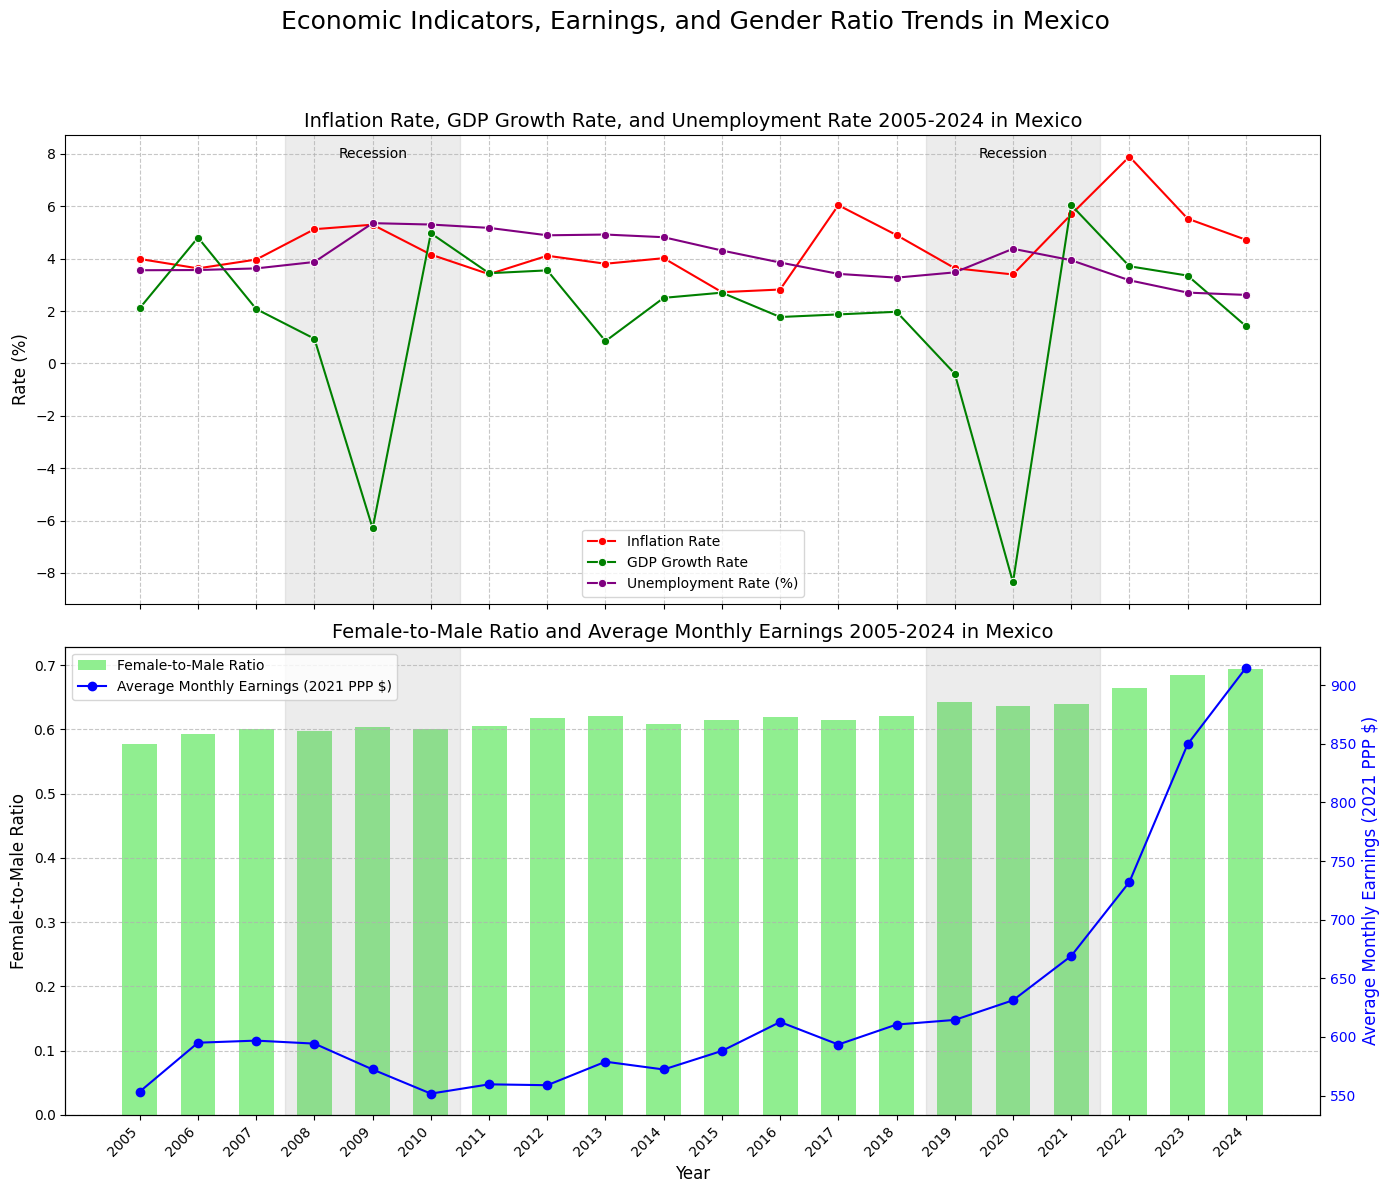

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the DataFrame is sorted by 'YEAR' for chronological plotting
df_sorted = df.sort_values(by='YEAR', ascending=True).copy()

# Create a figure with two vertically stacked subplots, sharing the x-axis
fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, figsize=(14, 12))

# --- Top Subplot: Macroeconomic Indicators (Line Chart) ---
# Plot Inflation Rate, GDP Growth Rate, and Unemployment Rate (%)
sns.lineplot(x='YEAR', y='Inflation Rate', data=df_sorted, label='Inflation Rate', marker='o', ax=ax0, color='red')
sns.lineplot(x='YEAR', y='GDP Growth Rate', data=df_sorted, label='GDP Growth Rate', marker='o', ax=ax0, color='green')
sns.lineplot(x='YEAR', y='Unemployment rate (%)', data=df_sorted, label='Unemployment Rate (%)', marker='o', ax=ax0, color='purple')

ax0.set_ylabel('Rate (%)', fontsize=12, color='black')
ax0.set_title('Inflation Rate, GDP Growth Rate, and Unemployment Rate 2005-2024 in Mexico', fontsize=14)
ax0.grid(True, linestyle='--', alpha=0.7)
ax0.legend(fontsize=10)

# --- Bottom Subplot: Gender Earnings Trends (Dual-Axis Chart) ---
# Female-to-Male Ratio as bars (left axis)
color_bars = 'lightgreen' # As per previous interaction
ax1.bar(df_sorted['YEAR'], df_sorted['Female-to-Male Ratio'], color=color_bars, label='Female-to-Male Ratio', width=0.6)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Female-to-Male Ratio', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black') # Y-axis ticks color for ax1
ax1.grid(True, linestyle='--', alpha=0.7, axis='y')

# Create a second y-axis sharing the same x-axis
ax1_twin = ax1.twinx()

# Average Monthly Earnings as a line (right axis)
color_line = 'blue' # As per previous interaction
ax1_twin.plot(df_sorted['YEAR'], df_sorted['Average monthly earnings (2021 PPP $)'], color=color_line, label='Average Monthly Earnings (2021 PPP $)', marker='o', linestyle='-')
ax1_twin.set_ylabel('Average Monthly Earnings (2021 PPP $)', color=color_line, fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor=color_line) # Y-axis ticks color for ax1_twin

ax1.set_title('Female-to-Male Ratio and Average Monthly Earnings 2005-2024 in Mexico', fontsize=14)

# Combine legends for the dual-axis subplot
handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
handles_ax1_twin, labels_ax1_twin = ax1_twin.get_legend_handles_labels()
ax1_twin.legend(handles_ax1 + handles_ax1_twin, labels_ax1 + labels_ax1_twin, loc='upper left', fontsize=10)

# Set x-axis ticks for both subplots (since they share x)
ax1.set_xticks(df_sorted['YEAR'])
ax1.set_xticklabels(df_sorted['YEAR'], rotation=45, ha='right') # Rotate x-axis labels for better readability

# --- Add shared light shading for highlighted periods ---
shading_alpha = 0.15 # Transparency for shading
shading_color = 'gray' # Color for shading

# Shading for 2008-2010 (covering years from 2007.5 to 2010.5 for full year highlights)
ax0.axvspan(2007.5, 2010.5, color=shading_color, alpha=shading_alpha)
ax1.axvspan(2007.5, 2010.5, color=shading_color, alpha=shading_alpha)
ax0.text(2009, ax0.get_ylim()[1]*0.95, 'Recession', color='black', ha='center', va='top', fontsize=10)

# Shading for 2019-2021 (covering years from 2018.5 to 2021.5)
ax0.axvspan(2018.5, 2021.5, color=shading_color, alpha=shading_alpha)
ax1.axvspan(2018.5, 2021.5, color=shading_color, alpha=shading_alpha)
ax0.text(2020, ax0.get_ylim()[1]*0.95, 'Recession', color='black', ha='center', va='top', fontsize=10)

# --- Full Figure Title ---
fig.suptitle('Economic Indicators, Earnings, and Gender Ratio Trends in Mexico', fontsize=18, y=1.02)

fig.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap and make space for suptitle
plt.show()